<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_Martech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Cargar el dataset
df = pd.read_csv('martech_homework_dataset_fixed.csv')

# 2. Ver la distribución de la variable objetivo
print("Distribución de Conversiones")
print(df['converted'].value_counts(normalize=True) * 100)

# 3. Encoding: Convertir texto a números
df_encoded = pd.get_dummies(df, columns=['device_type'], drop_first=True)

# 4. Separar X (features) e y (target)
X = df_encoded.drop(columns=['converted'])
y = df_encoded['converted']

# 5. Dividir en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 6. Escalamiento de datos
scaler = StandardScaler()
cols_to_scale = ['age', 'income', 'web_visits', 'time_on_site', 'past_purchases']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("\nDatos listos y escalados.")

Distribución de Conversiones
converted
0    70.0
1    30.0
Name: proportion, dtype: float64

Datos listos y escalados.


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# 1. Definición los modelos

# KNN: Se fija en los 5 vecinos más cercanos para decidir.
knn_model = KNeighborsClassifier(n_neighbors=5)

# Árbol de Decisión: Le ponemos max_depth=5.
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# SVM: Busca la frontera más ancha entre los que compran y los que no.
svm_model = SVC(probability=True, random_state=42)

# 2. Entrenamiento de los modelos
knn_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

print("Modelos entrenados con éxito.")

Modelos entrenados con éxito.



========== KNN ==========
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       140
           1       0.60      0.50      0.55        60

    accuracy                           0.75       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.74      0.75      0.74       200

ROC-AUC Score: 0.7994

========== Árbol de Decisión ==========
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       140
           1       0.60      0.52      0.55        60

    accuracy                           0.75       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.74      0.75      0.74       200

ROC-AUC Score: 0.7460

========== SVM ==========
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       140
           1       0.72      0.57      0.64        60

    accuracy                           0.81

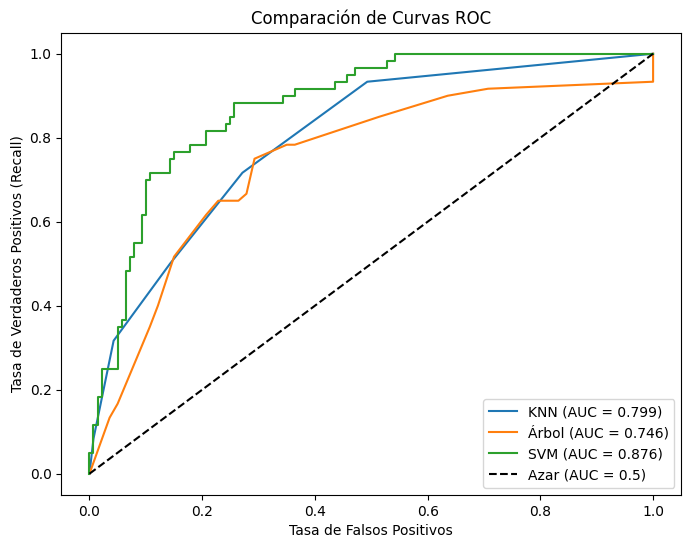

In [4]:
# Función para evaluar y mostrar reporte
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    print(f"\n{'='*10} {nombre} {'='*10}")
    print(classification_report(y_test, y_pred))
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {auc:.4f}")
    return y_proba

# Evaluar cada modelo
proba_knn = evaluar_modelo("KNN", knn_model, X_test, y_test)
proba_tree = evaluar_modelo("Árbol de Decisión", tree_model, X_test, y_test)
proba_svm = evaluar_modelo("SVM", svm_model, X_test, y_test)

# Grafico Curva ROC conjunta
fpr_knn, tpr_knn, _ = roc_curve(y_test, proba_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, proba_tree)
fpr_svm, tpr_svm, _ = roc_curve(y_test, proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, proba_knn):.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Árbol (AUC = {roc_auc_score(y_test, proba_tree):.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, proba_svm):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.title('Comparación de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend()
plt.show()

Importancia de Variables


,Variable,Importancia
4,time_on_site,0.473878
5,past_purchases,0.222427
1,income,0.137612
3,clicked_ad,0.126146
0,age,0.021283
2,web_visits,0.018655
6,device_type_mobile,0.000000
7,device_type_tablet,0.000000


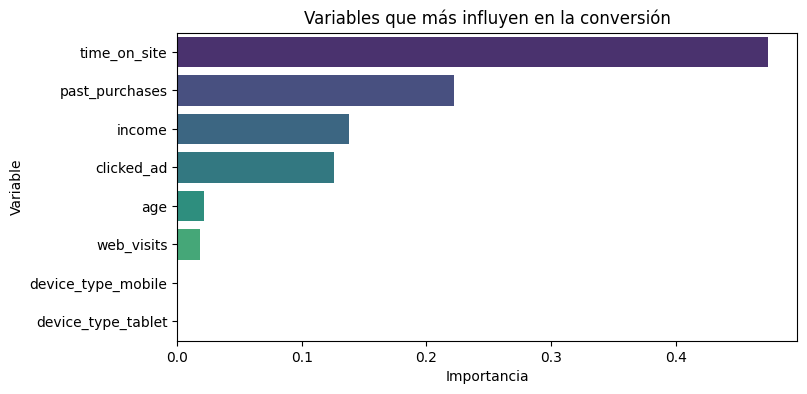

In [7]:
# Obten la importancia de cada variable según el Árbol de Decisión
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("Importancia de Variables")
display(importancias)

# Graficos
plt.figure(figsize=(8,4))
sns.barplot(data=importancias, x='Importancia', y='Variable', hue='Variable', palette='viridis', legend=False)
plt.title('Variables que más influyen en la conversión')
plt.show()

### Conclusiones del Caso Martech

**1. ¿Qué modelo tuvo mejor desempeño?**
Tras evaluar KNN, Árbol de Decisión y SVM, el modelo seleccionado es **SVM (Máquinas de Vectores de Soporte)**. La decisión se basa en nuestro objetivo de negocio: priorizar la detección de leads que sí van a convertir. SVM logró el **Recall más alto para la clase 1 (0.57)**, superando a los demás algoritmos. Además, su puntuación **ROC-AUC de 0.8761** es excelente, demostrando que es el modelo más robusto y preciso para separar a los compradores de los no compradores en este conjunto de datos.

**2. ¿Qué variable parece tener mayor peso en la clasificación?**
Analizando el indicador de *Feature Importances* del Árbol de Decisión, la variable **time_on_site (tiempo en el sitio)** es el factor determinante absoluto, concentrando casi el 47% del peso predictivo. Le sigue en importancia **past_purchases (compras pasadas)** con un 22%. Las variables demográficas (edad) y el tipo de dispositivo casi no tienen impacto en la decisión de compra.

**3. ¿Qué estrategia sugerirías al equipo de marketing con base en los resultados?**
* **Optimización de Presupuesto (Tiers):** Sugiero implementar nuestro modelo SVM como motor de *Scoring* para nuevos leads. Aquellos prospectos clasificados con predicción positiva (1) son los que deben recibir la inversión fuerte de marketing (retargeting agresivo, asesores telefónicos, descuentos exclusivos).
* **Foco en el Comportamiento Core (Engagement):** Dado que el `time_on_site` es el rey de la conversión, el equipo de marketing debe dejar de obsesionarse solo con conseguir "clics" (`clicked_ad` solo pesa un 12%) y cambiar su enfoque hacia la calidad del contenido. Necesitamos landing pages más interactivas, videos o calculadoras que retengan al usuario más tiempo en la web.
* **Aceptación de Falsos Positivos:** Nuestro modelo SVM asume que gastaremos algo de presupuesto en personas que finalmente no compren (nuestra Precisión es de 0.72), pero esto es operativamente mucho más barato que perder el costo de oportunidad de no impactar a un cliente que sí estaba a punto de comprar.